<a href="https://colab.research.google.com/github/LakshmiKanth11/Portfolio/blob/main/ANALYSIS_OF_EA_FC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EA Sports FC 27 Player Ratings — Exploratory **Analysis**

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

# **UPLOAD CSV FILE OR THE DATA FILE**

In [15]:
from google.colab import files

uploaded = files.upload()

Saving players.csv to players (1).csv


In [16]:
import io

filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()

,player_id,common_name,first_name,last_name,overall_rating,position,alternate_positions,club,league,nationality,gender,preferred_foot,skill_moves,weak_foot,height_cm,weight_kg,birthdate,playstyles,pace,shooting,passing,dribbling,defending,physicality,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,edition,snapshot_date
0,227203,Alexia Putellas,Alexia,Putellas Segura,91,CM,CAM ST,London City,Barclays WSL,Spain,Women's Football,Left,5,5,NaN,NaN,04-02-1994,"Finesse Shot, Gamechanger, Tiki Taka, Inventiv...",80,90,91,92,72,75,88,90,74,94,87,91,89,83,90,94,80,80,87,92,92,89,82,80,74,90,70,78,91,93,89,92,60,82,64,15,17,11,15,10,fc27,12-09-2026
1,231747,NaN,Kylian,Mbappé,91,ST,LW,Real Madrid,LALIGA EA SPORTS,France,Men's Football,Right,5,4,NaN,NaN,20-12-1998,"Finesse Shot, Acrobatic, Low Driven Shot, Game...",96,91,80,92,29,76,74,95,78,87,87,92,80,70,74,93,97,96,93,92,82,91,90,83,77,86,61,19,91,83,86,88,15,34,24,13,5,7,11,6,fc27,12-09-2026
2,239085,NaN,Erling,Haaland,91,ST,NaN,Manchester City,Premier League,Norway,Men's Football,Left,3,3,NaN,NaN,21-07-2000,"Chip Shot, Power Shot, Precision Header, Acrob...",87,92,71,80,47,89,58,96,85,78,90,79,77,62,66,83,81,92,66,94,69,94,93,80,93,83,88,43,95,75,89,86,42,47,33,7,14,13,11,7,fc27,12-09-2026
3,192119,NaN,Thibaut,Courtois,90,GK,NaN,Real Madrid,LALIGA EA SPORTS,Belgium,Men's Football,Left,1,3,NaN,NaN,11-05-1992,"Far Throw, Far Reach, Rush Out+",87,89,78,90,46,90,14,14,13,33,12,13,19,20,35,23,42,52,63,88,45,59,68,38,70,17,23,15,13,60,27,66,20,18,16,87,89,78,90,90,fc27,12-09-2026
4,202126,NaN,Harry,Kane,90,ST,NaN,FC Bayern München,Bundesliga,England,Men's Football,Right,3,4,NaN,NaN,28-07-1993,"Precision Header, Low Driven Shot, Gamechanger...",62,94,83,82,49,83,80,96,89,86,91,80,82,69,82,87,63,62,67,94,72,92,87,76,87,91,82,42,96,86,93,92,46,44,42,8,10,11,14,11,fc27,12-09-2026


## 2. Dataset overview

In [21]:
df["birthdate"] = pd.to_datetime(df["birthdate"], dayfirst=True)
snapshot = pd.to_datetime(df["snapshot_date"].iloc[0], dayfirst=True)
df["age"] = ((snapshot - df["birthdate"]).dt.days / 365.25).astype(int)

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Unique players: {df['player_id'].nunique():,}")
print(f"Clubs: {df['club'].nunique()} | Leagues: {df['league'].nunique()} | Nationalities: {df['nationality'].nunique()}")
df["gender"].value_counts()

Rows: 19,789 | Columns: 61
Unique players: 19,789
Clubs: 702 | Leagues: 63 | Nationalities: 164


,count
gender,
Men's Football,17849
Women's Football,1940


## 3. Overall rating distribution

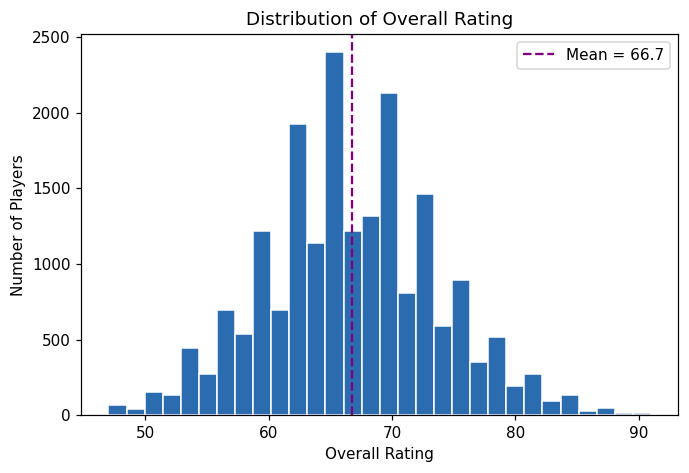

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df["overall_rating"], bins=30, color="#2b6cb0", edgecolor="white")
ax.set_title("Distribution of Overall Rating")
ax.set_xlabel("Overall Rating")
ax.set_ylabel("Number of Players")
ax.axvline(df["overall_rating"].mean(), color="purple", linestyle="--",
           label=f"Mean = {df['overall_rating'].mean():.1f}")
ax.legend()
plt.show()

## 4. Top 20 players by overall rating

In [23]:
top20 = df.nlargest(20, "overall_rating")[
    ["common_name", "first_name", "last_name", "position", "club", "nationality", "overall_rating", "age"]
].copy()
top20["display_name"] = top20["common_name"].fillna(top20["first_name"] + " " + top20["last_name"])
top20[["display_name", "position", "club", "nationality", "overall_rating", "age"]]

,display_name,position,club,nationality,overall_rating,age
0,Alexia Putellas,CM,London City,Spain,91,32
1,Kylian Mbappé,ST,Real Madrid,France,91,27
2,Erling Haaland,ST,Manchester City,Norway,91,26
3,Thibaut Courtois,GK,Real Madrid,Belgium,90,34
4,Harry Kane,ST,FC Bayern München,England,90,33
5,Ousmane Dembélé,ST,Paris SG,France,90,29
6,Rodri,CDM,FC Barcelona,Spain,90,30
7,Aitana Bonmatí,CM,FC Barcelona,Spain,90,28
8,Khadija Shaw,ST,Manchester City,Jamaica,90,29
9,Michael Olise,RM,FC Bayern München,France,90,24


## 5. Average rating by position

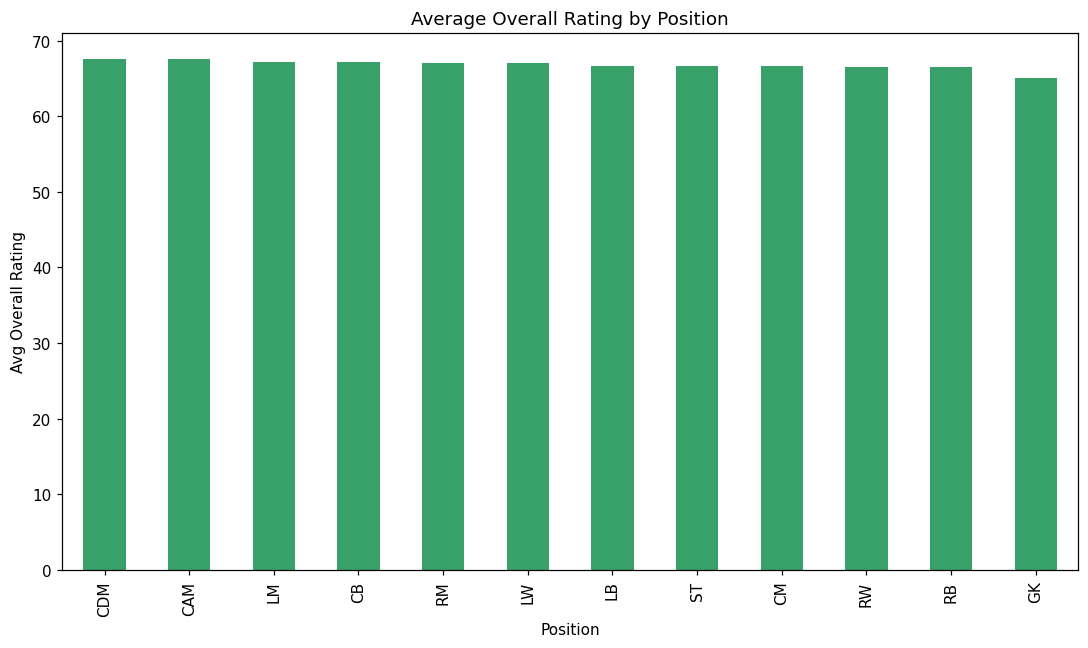

In [24]:
pos_rating = df.groupby("position")["overall_rating"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
pos_rating.plot(kind="bar", ax=ax, color="#38a169")
ax.set_title("Average Overall Rating by Position")
ax.set_xlabel("Position")
ax.set_ylabel("Avg Overall Rating")
plt.tight_layout()
plt.show()

## 6. Top 15 nationalities by player count

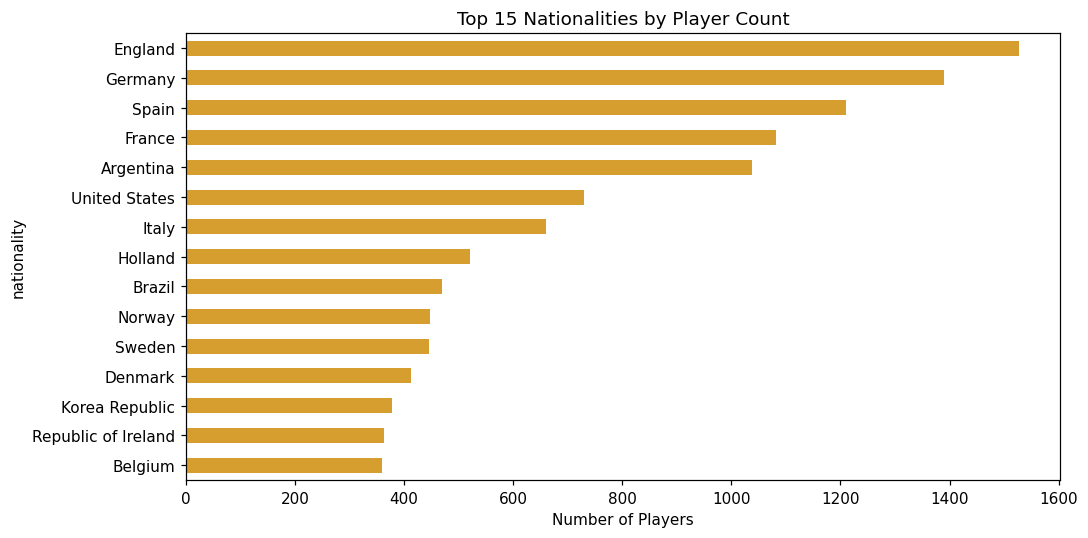

In [25]:
nat_counts = df["nationality"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
nat_counts.sort_values().plot(kind="barh", ax=ax, color="#d69e2e")
ax.set_title("Top 15 Nationalities by Player Count")
ax.set_xlabel("Number of Players")
plt.tight_layout()
plt.show()

## 7. What drives the rating? Attribute correlations

passing        0.736
dribbling      0.723
physicality    0.578
shooting       0.475
defending      0.379
pace           0.323
Name: overall_rating, dtype: float64


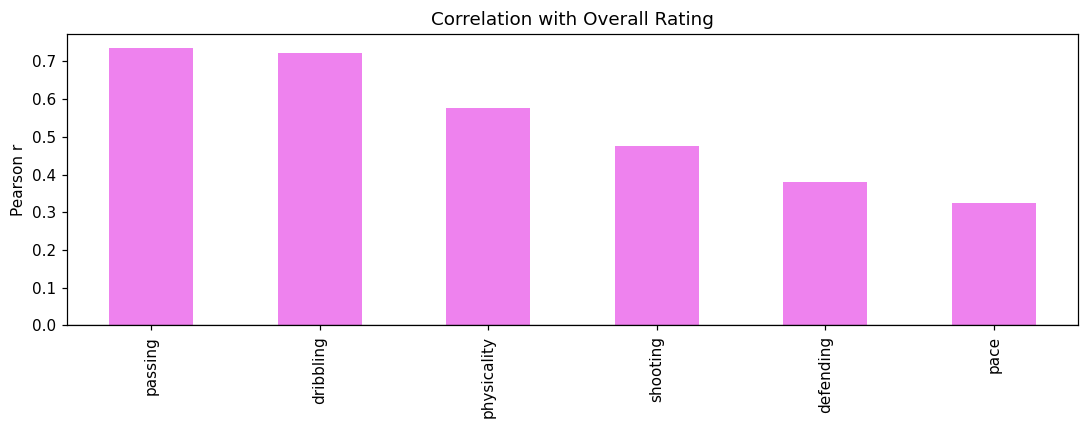

In [26]:
key_attrs = ["pace", "shooting", "passing", "dribbling", "defending", "physicality"]
corr = df[key_attrs + ["overall_rating"]].corr()["overall_rating"].drop("overall_rating").sort_values(ascending=False)
print(corr.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
corr.plot(kind="bar", ax=ax, color="violet")
ax.set_title("Correlation with Overall Rating")
ax.set_ylabel("Pearson r")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 8. Attribute profile by position (outfield only)

In [27]:
outfield = df[df["position"] != "GK"]
profile = outfield.groupby("position")[key_attrs].mean().round(1)
profile

,pace,shooting,passing,dribbling,defending,physicality
position,,,,,,
CAM,69.8,62.7,65.5,69.5,45.4,58.3
CB,60.6,36.9,51.0,54.2,66.9,71.6
CDM,62.2,53.2,62.4,64.7,64.8,68.7
CM,65.8,59.1,64.7,67.4,59.5,64.5
LB,72.6,47.3,59.5,64.0,62.5,64.9
LM,77.1,61.3,61.8,68.7,40.3,58.5
LW,77.3,63.1,61.3,69.1,34.7,57.1
RB,72.7,46.6,58.6,63.3,62.5,65.4
RM,77.0,61.2,61.9,68.4,41.3,58.5


## 9. Age distribution

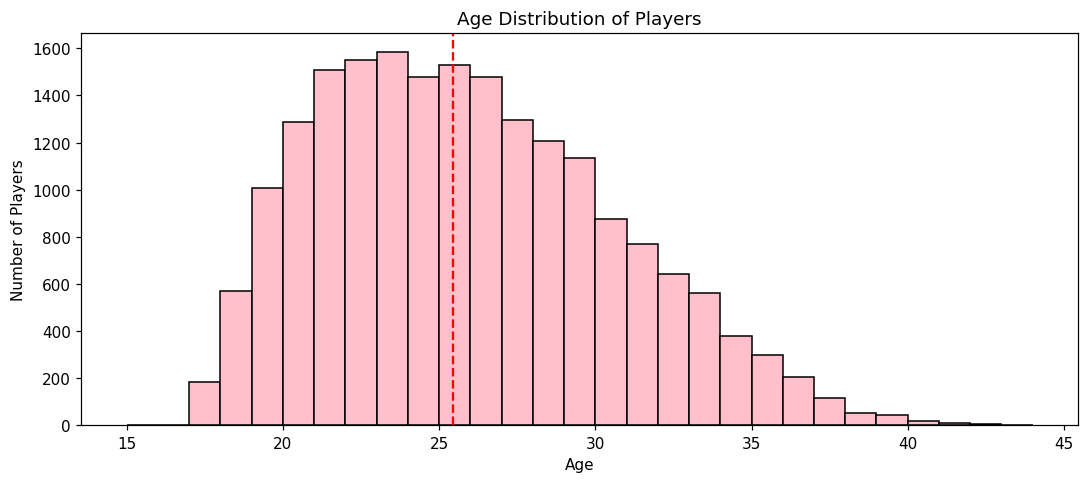

In [28]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(df["age"], bins=range(15, 45), color="pink", edgecolor="black")
ax.set_title("Age Distribution of Players")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Players")
ax.axvline(df["age"].mean(), color="red", linestyle="--",
           label=f"Mean = {df['age'].mean():.1f}")
plt.tight_layout()
plt.show()

## 10. Men's vs Women's football rating comparison

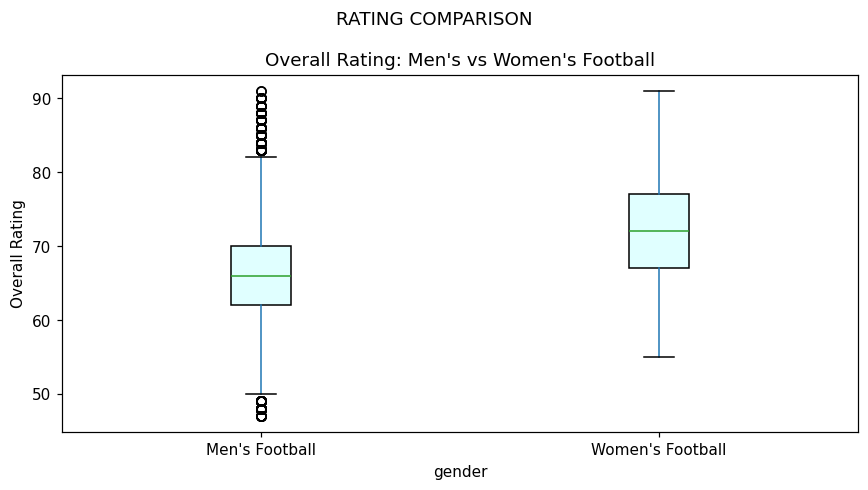

In [29]:
fig, ax = plt.subplots(figsize=(8, 4.5))
df.boxplot(column="overall_rating", by="gender", ax=ax, grid=False,
           patch_artist=True, boxprops=dict(facecolor="lightcyan"))
ax.set_title("Overall Rating: Men's vs Women's Football")
ax.set_ylabel("Overall Rating")
plt.suptitle("RATING COMPARISON")
plt.tight_layout()
plt.show()

## 11. Set up name search

Builds a lowercase, accent-stripped name field so "mbappe" matches "Mbappé".

In [30]:
def strip_accents(s):
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

df["search_name"] = (df["common_name"].fillna("") + " " + df["first_name"] + " " + df["last_name"]).str.lower()
df["search_name"] = df["search_name"].apply(strip_accents)

def search_player(query):
    q = strip_accents(query.lower())
    mask = df["search_name"].str.contains(q, na=False)
    cols = ["player_id", "common_name", "first_name", "last_name", "position", "club", "league", "overall_rating"]
    return df[mask][cols].sort_values("overall_rating", ascending=False)

## 12. Define attribute vectors

Goalkeepers and outfield players use different attribute sets — comparing a GK's shot power to a striker's isn't meaningful, so each player is only compared against others in the same group. `pace`/`shooting`/etc. (the 6 headline stats) are combined with the ~28 detailed sub-attributes for a finer-grained match.

In [31]:
CORE = ["pace", "shooting", "passing", "dribbling", "defending", "physicality"]

OUTFIELD_ATTRS = CORE + [
    "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy", "attacking_short_passing", "attacking_volleys",
    "skill_dribbling", "skill_curve", "skill_fk_accuracy", "skill_long_passing", "skill_ball_control",
    "movement_acceleration", "movement_sprint_speed", "movement_agility", "movement_reactions", "movement_balance",
    "power_shot_power", "power_jumping", "power_stamina", "power_strength", "power_long_shots",
    "mentality_aggression", "mentality_interceptions", "mentality_positioning", "mentality_vision", "mentality_penalties", "mentality_composure",
    "defending_awareness", "defending_standing_tackle", "defending_sliding_tackle",
]

GK_ATTRS = [
    "goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking", "goalkeeping_positioning", "goalkeeping_reflexes",
    "movement_reactions", "movement_agility", "power_jumping", "power_strength", "mentality_composure",
]

## 13. Similarity engine

In [32]:
def find_similar(player_id, top_n=10):
    target = df[df["player_id"] == player_id].iloc[0]
    is_gk = target["position"] == "GK"
    attrs = GK_ATTRS if is_gk else OUTFIELD_ATTRS

    # Compare only within the same broad group (GK vs outfield)
    pool = df[(df["position"] == "GK") == is_gk].reset_index(drop=True)

    X = StandardScaler().fit_transform(pool[attrs])
    target_pos = pool.index[pool["player_id"] == player_id][0]
    sims = cosine_similarity(X[target_pos:target_pos + 1], X)[0]

    pool = pool.assign(similarity=sims)
    result = pool[pool["player_id"] != player_id].sort_values("similarity", ascending=False).head(top_n)
    result = result.assign(display_name=result["common_name"].fillna(result["first_name"] + " " + result["last_name"]))

    dname = target["common_name"] if pd.notna(target["common_name"]) else f"{target['first_name']} {target['last_name']}"
    print(f"Most similar to {dname} ({target['position']}, {target['club']}, OVR {target['overall_rating']}):\n")

    cols = ["display_name", "position", "club", "league", "overall_rating", "similarity"]
    return result[cols].round({"similarity": 3}).reset_index(drop=True)

## 14. Search wrapper

`scout("name")` looks up the player and shows the closest matches. If several players share a name, it defaults to the highest-rated and tells you so — pass a fuller name (or call `search_player()` yourself) to disambiguate.

In [33]:
def scout(query, top_n=10):
    matches = search_player(query)
    if len(matches) == 0:
        print("No players found matching:", query)
        return None
    top_id = matches.iloc[0]["player_id"]
    if len(matches) > 1:
        top = matches.iloc[0]
        print(f"{len(matches)} matches for '{query}' — defaulting to top-rated: "
              f"{top['first_name']} {top['last_name']} ({top['club']}, OVR {top['overall_rating']})\n")
    return find_similar(top_id, top_n=top_n)

## 15.  EXAMPLE OF SEARCHING SIMILAR PLAYERS


In [34]:
scout("Mbappe")


2 matches for 'Mbappe' — defaulting to top-rated: Kylian Mbappé (Real Madrid, OVR 91)

Most similar to Kylian Mbappé (ST, Real Madrid, OVR 91):



,display_name,position,club,league,overall_rating,similarity
0,Albert Guðmundsson,ST,Fiorentina,Serie A Enilive,77,0.981
1,Ferran Torres,ST,Paris SG,Ligue 1 McDonald's,84,0.979
2,Ismaïla Sarr,RW,Crystal Palace,Premier League,81,0.978
3,Donyell Malen,ST,AS Roma,Serie A Enilive,83,0.975
4,Sophia Wilson,ST,Portland Thorns,NWSL,88,0.974
5,Georges Mikautadze,ST,Villarreal CF,LALIGA EA SPORTS,79,0.974
6,Soufiane Rahimi,ST,Al Ain FC,United Emirates League,78,0.972
7,Ademola Lookman,ST,Atlético de Madrid,LALIGA EA SPORTS,83,0.972
8,Karim Adeyemi,RM,FC Barcelona,LALIGA EA SPORTS,82,0.971
9,Melvine Malard,LM,Chelsea,Barclays WSL,84,0.971


In [35]:
# See every match before picking one, when a name is common
search_player("KYLIAN")

,player_id,common_name,first_name,last_name,position,club,league,overall_rating
1,231747,NaN,Kylian,Mbappé,ST,Real Madrid,LALIGA EA SPORTS,91
11073,270886,NaN,Kyliane,Dong,LM,Bolton,EFL Championship,66
16798,263387,NaN,Kylian,Kouassi,ST,Blackpool,EFL League One,60


In [36]:
# Once you know the exact player_id from search_player(), go straight to it
find_similar(player_id=231747, top_n=10)  # 231747 = Kylian Mbappé; swap in any player_id from the tables above

Most similar to Kylian Mbappé (ST, Real Madrid, OVR 91):



,display_name,position,club,league,overall_rating,similarity
0,Albert Guðmundsson,ST,Fiorentina,Serie A Enilive,77,0.981
1,Ferran Torres,ST,Paris SG,Ligue 1 McDonald's,84,0.979
2,Ismaïla Sarr,RW,Crystal Palace,Premier League,81,0.978
3,Donyell Malen,ST,AS Roma,Serie A Enilive,83,0.975
4,Sophia Wilson,ST,Portland Thorns,NWSL,88,0.974
5,Georges Mikautadze,ST,Villarreal CF,LALIGA EA SPORTS,79,0.974
6,Soufiane Rahimi,ST,Al Ain FC,United Emirates League,78,0.972
7,Ademola Lookman,ST,Atlético de Madrid,LALIGA EA SPORTS,83,0.972
8,Karim Adeyemi,RM,FC Barcelona,LALIGA EA SPORTS,82,0.971
9,Melvine Malard,LM,Chelsea,Barclays WSL,84,0.971


# FC27 Predictive Modeling

Two models on the same dataset:
1. **Regression** — predict `overall_rating` from the raw attribute columns
2. **Classification** — predict `position` from "playing style" attributes

Both use Random Forests, which give feature importances for free alongside solid accuracy.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                              accuracy_score, classification_report, confusion_matrix)

plt.rcParams["figure.dpi"] = 110

## 1. Feature sets

Same split used in the scouting notebook, for the same reason: a goalkeeper's outfield attributes
(finishing, tackling) are near-meaningless low placeholder values, and vice versa for an outfielder's
goalkeeping stats. `height_cm`/`weight_kg` are dropped — they're empty for every row in this file.

In [38]:
CORE = ["pace", "shooting", "passing", "dribbling", "defending", "physicality"]

OUTFIELD_DETAILED = [
    "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy", "attacking_short_passing", "attacking_volleys",
    "skill_dribbling", "skill_curve", "skill_fk_accuracy", "skill_long_passing", "skill_ball_control",
    "movement_acceleration", "movement_sprint_speed", "movement_agility", "movement_reactions", "movement_balance",
    "power_shot_power", "power_jumping", "power_stamina", "power_strength", "power_long_shots",
    "mentality_aggression", "mentality_interceptions", "mentality_positioning", "mentality_vision", "mentality_penalties", "mentality_composure",
    "defending_awareness", "defending_standing_tackle", "defending_sliding_tackle",
]

GK_DETAILED = ["goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking", "goalkeeping_positioning", "goalkeeping_reflexes"]
EXTRA = ["skill_moves", "weak_foot"]

# Regression uses everyone (GK + outfield), so it needs both attribute groups
ALL_ATTRS = sorted(set(CORE + OUTFIELD_DETAILED + GK_DETAILED + EXTRA))

# Classification restricts to outfield players, so it only needs outfield-relevant attributes
OUTFIELD_ATTRS = CORE + OUTFIELD_DETAILED + EXTRA

print(f"Regression features: {len(ALL_ATTRS)}")
print(f"Classifier features: {len(OUTFIELD_ATTRS)}")

Regression features: 42
Classifier features: 37


## 2. Regression — predict `overall_rating`

Random Forest, 80/20 train/test split, 200 trees.

In [39]:
X = df[ALL_ATTRS]
y = df["overall_rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
mae = mean_absolute_error(y_test, pred)

print(f"R2:   {r2:.4f}")
print(f"RMSE: {rmse:.3f} rating points")
print(f"MAE:  {mae:.3f} rating points")

R2:   0.9771
RMSE: 1.025 rating points
MAE:  0.766 rating points


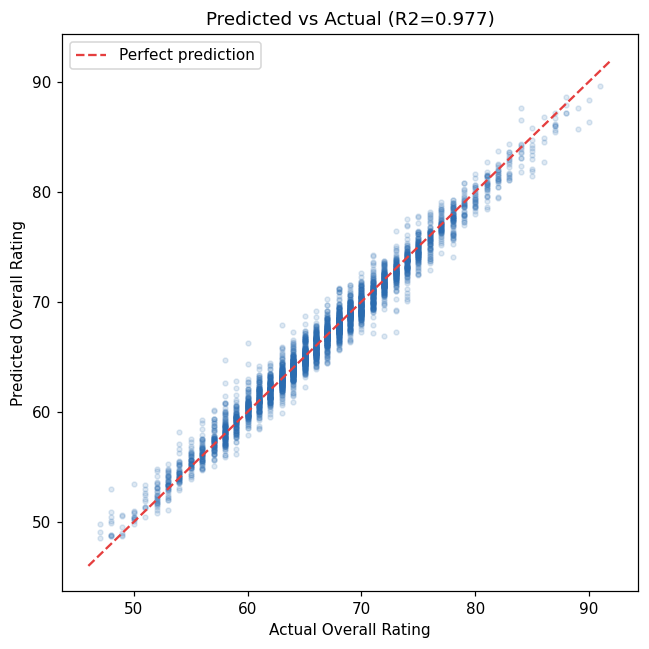

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred, alpha=0.15, s=10, color="#2b6cb0")
lims = [y_test.min() - 1, y_test.max() + 1]
ax.plot(lims, lims, color="#e53e3e", linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual Overall Rating")
ax.set_ylabel("Predicted Overall Rating")
ax.set_title(f"Predicted vs Actual (R2={r2:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

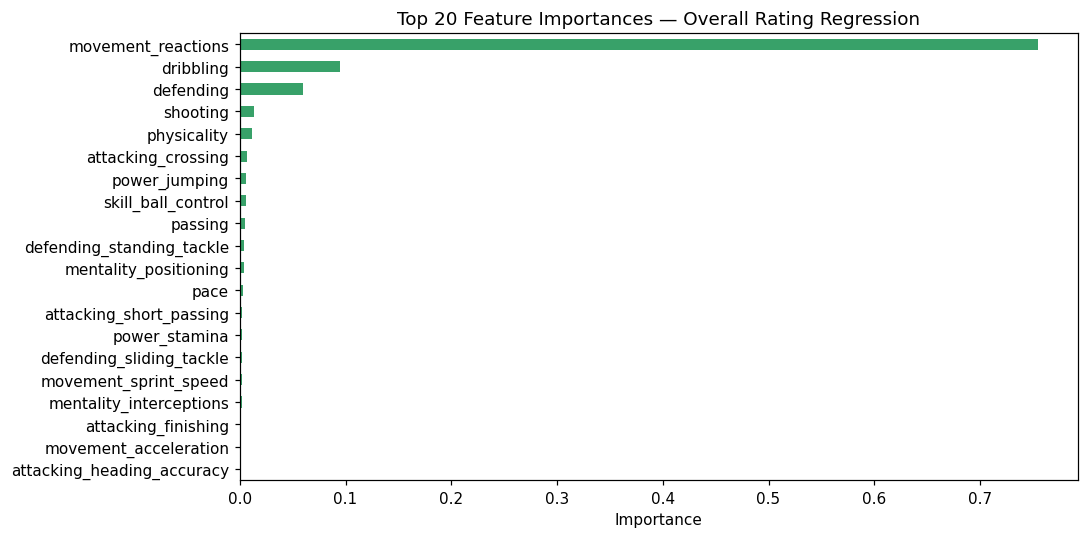

,0
movement_reactions,0.754928
dribbling,0.094980
defending,0.060202
shooting,0.013503
physicality,0.011864
attacking_crossing,0.006473
power_jumping,0.006302
skill_ball_control,0.005804
passing,0.005011
defending_standing_tackle,0.004277


In [43]:
reg_importance = pd.Series(reg.feature_importances_, index=ALL_ATTRS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
reg_importance.head(20).sort_values().plot(kind="barh", ax=ax, color="#38a169")
ax.set_title("Top 20 Feature Importances — Overall Rating Regression")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

reg_importance.head(10)

**What this shows:** with these 42 attributes, the model gets R² ≈ 0.977 — it explains ~98% of the
variance in `overall_rating`, missing by about 1 point on average (MAE ≈ 0.77). One feature dominates:
`movement_reactions`                                                       alone typically accounts **for ~75% of total importance**, dwarfing every other stat
(`dribbling` and `defending` are a distant second and third). That's a real property of how these games compute
overall rating — "Reactions" is heavily weighted across almost every position — not an artifact of this model.

## 3. Classification — predict `position` from playing style

Restricted to outfield players only (12 → 11 classes, GK dropped). `class_weight="balanced"` compensates for
CB (deepest position pool) outnumbering LW/RW roughly 7 to 1.

In [44]:
outfield_df = df[df["position"] != "GK"].copy()
Xc = outfield_df[OUTFIELD_ATTRS]
yc = outfield_df["position"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced")
clf.fit(Xc_train, yc_train)
pred_c = clf.predict(Xc_test)

acc = accuracy_score(yc_test, pred_c)
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(yc_test, pred_c))

Accuracy: 0.6597

              precision    recall  f1-score   support

         CAM       0.56      0.56      0.56       233
          CB       0.90      0.93      0.91       719
         CDM       0.71      0.60      0.65       314
          CM       0.64      0.84      0.72       475
          LB       0.51      0.45      0.48       287
          LM       0.32      0.30      0.31       230
          LW       0.12      0.03      0.05        98
          RB       0.48      0.51      0.50       306
          RM       0.32      0.24      0.27       215
          RW       0.35      0.06      0.11        97
          ST       0.80      0.95      0.87       543

    accuracy                           0.66      3517
   macro avg       0.52      0.50      0.49      3517
weighted avg       0.63      0.66      0.64      3517



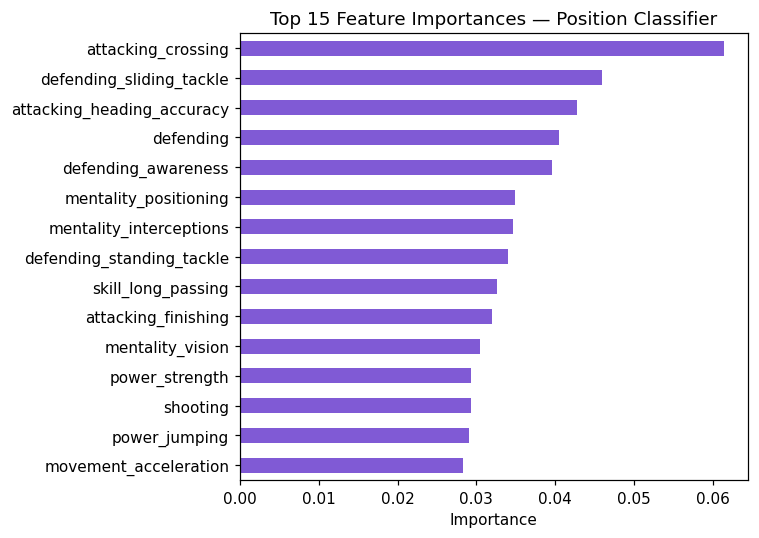

,0
attacking_crossing,0.061384
defending_sliding_tackle,0.045962
attacking_heading_accuracy,0.042820
defending,0.040509
defending_awareness,0.039588
mentality_positioning,0.034899
mentality_interceptions,0.034618
defending_standing_tackle,0.034053
skill_long_passing,0.032644
attacking_finishing,0.032027


In [49]:
clf_importance = pd.Series(clf.feature_importances_, index=OUTFIELD_ATTRS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
clf_importance.head(15).sort_values().plot(kind="barh", ax=ax, color="#805ad5")
ax.set_title("Top 15 Feature Importances — Position Classifier")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

clf_importance.head(10)

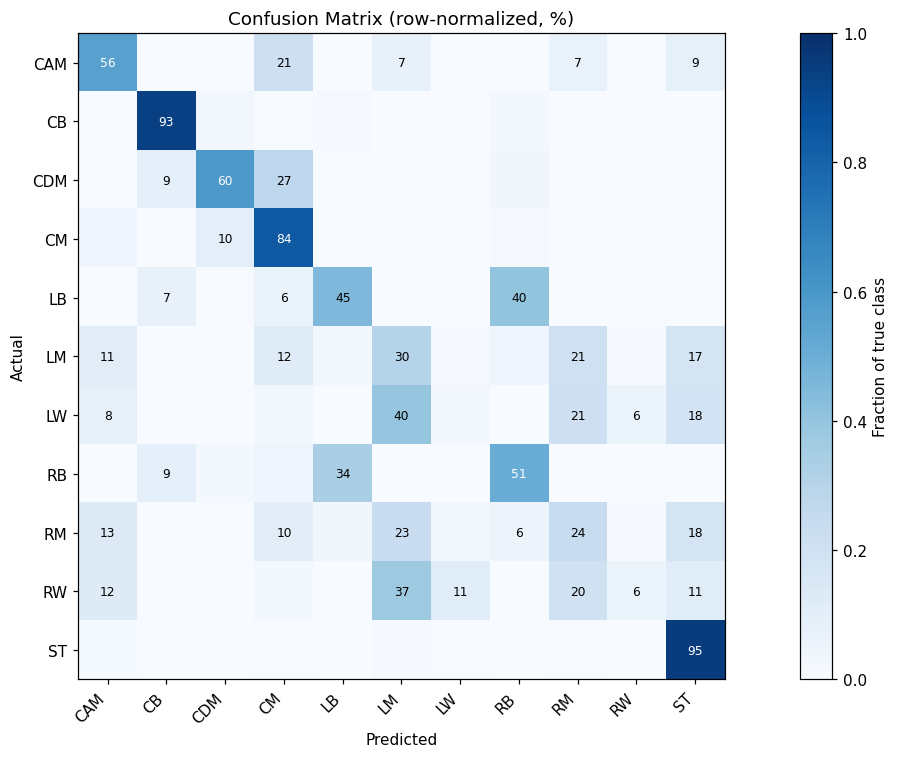

In [47]:
labels = sorted(yc.unique())
cm = confusion_matrix(yc_test, pred_c, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (row-normalized, %)")
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm[i, j]
        if v > 0.05:
            ax.text(j, i, f"{v*100:.0f}", ha="center", va="center",
                     color="white" if v > 0.5 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="Fraction of true class")
plt.tight_layout()
plt.show()

**What this shows:** accuracy lands around **66%** on 11 classes (random guessing ≈ 9%), but the errors are the
real story, visible in the confusion matrix:

- **CB (≈93% recall)** and **ST (≈95% recall)** are almost never confused with anything — their attribute
  profiles are extremes (max defending / min pace vs. max shooting / min defending).
- **LB ↔ RB** and **LM ↔ RM ↔ LW ↔ RW** confuse each other constantly, and always with their *mirror* side.
  That's not a model weakness — a left-back and a right-back need identical skills, just on opposite flanks.
  Nothing in these attribute columns encodes which foot of the pitch a player lines up on, so the model
  structurally cannot separate them. Adding `preferred_foot` as a feature would likely fix most of this.
- **CDM ↔ CM ↔ CAM** blur into each other along a single axis (defensive → attacking central midfielder),
  which matches how those roles are actually coached — a gradient, not three hard categories.

In [50]:
import seaborn as sns
%matplotlib inline

/tmp/ipykernel_884/21501924.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_players, x='overall_rating', y='league', palette='crest')


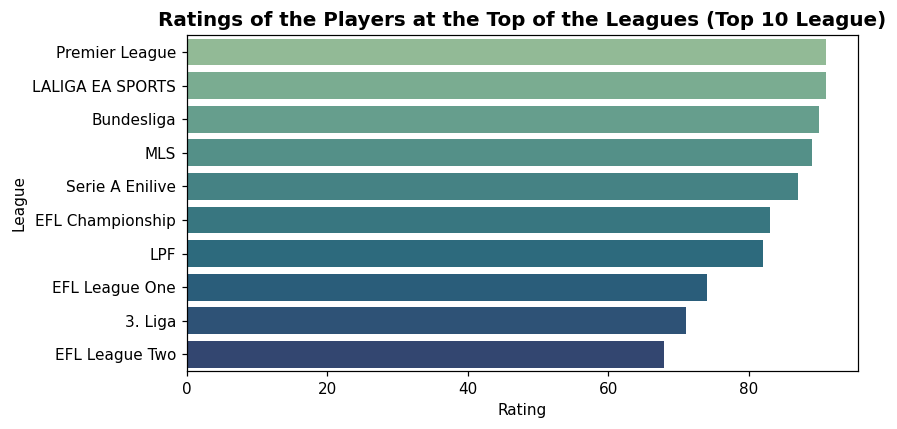

In [55]:
# First, find the top 10 leagues by player count
top_leagues = df["league"].value_counts().head(10).index

# Get the highest-rated player (or group of players) from each of these top leagues
best_players = df[df["league"].isin(top_leagues)].sort_values("overall_rating", ascending=False).drop_duplicates(subset=["league"])

plt.figure(figsize=(8,4))
sns.barplot(data=best_players, x='overall_rating', y='league', palette='crest')
plt.title('Ratings of the Players at the Top of the Leagues (Top 10 League)', fontsize=13, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('League')
plt.tight_layout()
plt.show()